# Classification
In this notebook you will go through a classification problem, through which you are going to predict a categorical value, i.e., a class.

# Setup


In [1]:
# Common imports
import numpy as np
import os
import pickle

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
DATA_DIR = os.path.join(PROJECT_ROOT_DIR,'data')
IMG_DIR = os.path.join(PROJECT_ROOT_DIR, 'img')
CHAPTER_ID = "classification"


def save_fig(fig_id, tight_layout=True):
    path = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID, fig_id + ".png")
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format='png', dpi=300)

In [2]:
import warnings
warnings.filterwarnings("ignore")

## MNIST
MNIST is likely the most famous dataset in ML.

It is a collection of 70.000 handwritten digits. 

Each image is associated with its actual digit.

`sklearn` provides some helper function to fetch this dataset.

**Warning**: `fetch_mldata()` is deprecated since Scikit-Learn 0.20. You should use `fetch_openml()` instead. However, it returns the unsorted MNIST dataset, whereas `fetch_mldata()` returned the dataset sorted by target (the training set and the test test were sorted separately). In general, this is fine, but if you want to get the exact same results as before, you need to sort the dataset using the following function:

In [3]:
def sort_by_target(mnist):
    reorder_train = np.array(sorted([(target, i) for i, target in enumerate(mnist.target[:60000])]))[:, 1]
    reorder_test = np.array(sorted([(target, i) for i, target in enumerate(mnist.target[60000:])]))[:, 1]
    mnist.data[:60000] = mnist.data.iloc[reorder_train]
    mnist.target[:60000] = mnist.target.iloc[reorder_train]
    mnist.data[60000:] = mnist.data.iloc[reorder_test + 60000]
    mnist.target[60000:] = mnist.target.iloc[reorder_test + 60000]

In [4]:
def maybe_download_mnist():
    if not os.path.isdir(DATA_DIR):
        os.mkdir(DATA_DIR)
    download = False
    if not os.listdir(DATA_DIR):
        download = True
        # empty directory download the file
        try:
            from sklearn.datasets import fetch_openml
            mnist = fetch_openml('mnist_784', version=1, cache=True)
            mnist.target = mnist.target.astype(np.int8) # fetch_openml() returns targets as strings
            sort_by_target(mnist) # fetch_openml() returns an unsorted dataset
        except ImportError:
            from sklearn.datasets import fetch_mldata
            mnist = fetch_mldata('MNIST original')
    mode = 'wb' if download else 'rb'
    with open(os.path.join(DATA_DIR,'mnist.pickle'), mode) as f:
        if download:
            pickle.dump(mnist, f)
        else:
            mnist = pickle.load(f)
    return mnist

mnist = maybe_download_mnist()

The object you just downloaded has a dict-like structure.

The actual data are stored in the ``.data`` field of the object.


In [5]:
print([k for k in mnist])

['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url']


Take a look at the shape of your dataset. 


In [6]:
mnist.data.shape

(70000, 784)

In [7]:
mnist.data

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
mnist.target

0        0
1        0
2        0
3        0
4        0
        ..
69995    9
69996    9
69997    9
69998    9
69999    9
Name: class, Length: 70000, dtype: int8

In [9]:
X, y = mnist["data"].values, mnist["target"].values
X.shape

(70000, 784)

In [10]:
y.shape

(70000,)

In [11]:
28*28

784

There are 70.000 images with 784 features. 
Each feature represents the density of a pixel, ranging from 0 to 255.

Each row is the rollout vector of a 28x28 image.

You can plot some data by reshaping the vector into the original matrix and then you
can use ``matplotlib.imshow``.

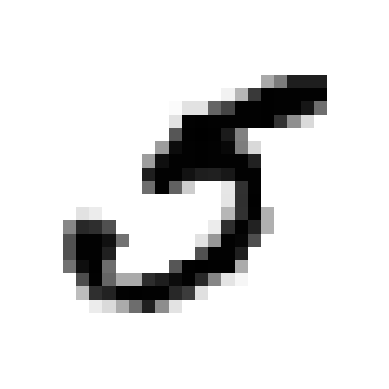

In [12]:
some_digit = X[36000]

def draw(sample, save_path = None):
    some_digit_image = some_digit.reshape(28, 28)
    plt.imshow(some_digit_image, cmap = mpl.cm.binary,
           interpolation="nearest")
    plt.axis("off")
    if save_path is not None:
        save_fig(os.path.join(IMG_DIR, save_path))

draw(some_digit)

In [13]:

def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

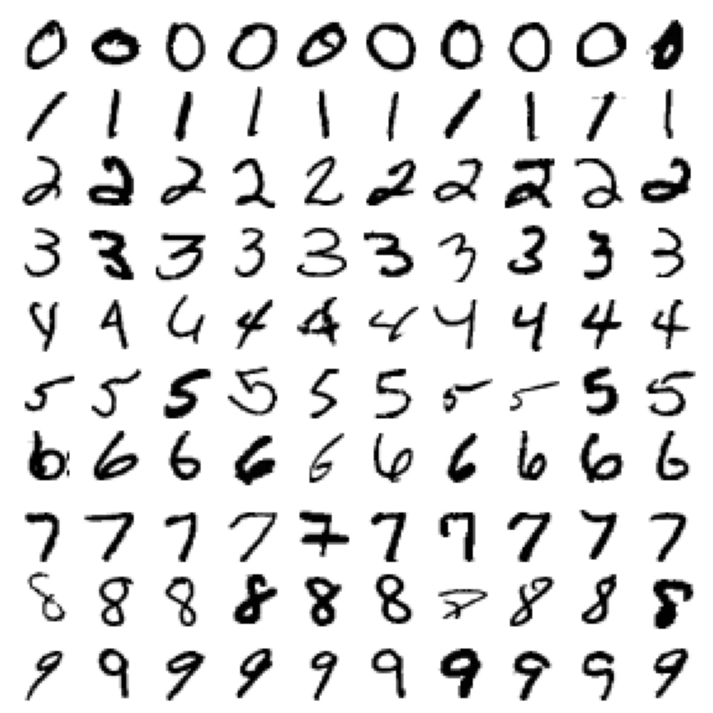

In [14]:
plt.figure(figsize=(9,9))
example_images = np.r_[X[:12000:600], X[13000:30600:600], X[30600:60000:590]]
plot_digits(example_images, images_per_row=10)
plt.show()

Now let's split the data

In [15]:
# !pip install scikit-learn

In [16]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=1/7, random_state=42 )
X_train.shape


(60000, 784)

X sono le features (matrice dei pixel), y le variabili delle label corrispondenti

# Training a Binary Classifier

Before diving into the details of the problem,
let's focus on slightly simpler sub-problem. 

You have to train a _binary classifier_.

The label _5__ is regarded as the positive class.

Let's create the new target vector for this problem.

In [17]:
y_train

array([3, 5, 3, ..., 9, 0, 2], shape=(60000,), dtype=int8)

In [18]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)
y_train_5

array([False,  True, False, ..., False, False, False], shape=(60000,))

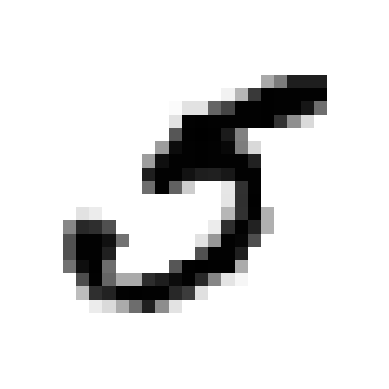

In [19]:
some_digit = X[36000]
draw(some_digit)

Let's pick the **Stochastic Gradient Descent** classifier and train it upon the 
new dataset. (in realtà noi usiamo l'albero decisionale)

The main advantage of this classifier is its ability to handle large datasets in a very efficient way.


In [87]:
#from sklearn.linear_model import SGDClassifier
# train it yourself
#sgd_clf = SGDClassifier(max_iter=5, tol=1e-3, random_state=42)

from sklearn.tree import DecisionTreeClassifier
sgd_clf = DecisionTreeClassifier(max_depth=10, random_state=42)

sgd_clf.fit(X_train, y_train_5)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

Per rimuovere la componente random, aggiungo il seed o random_state.

In [88]:
some_digit

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,  86, 131, 225, 225, 225,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [89]:
sgd_clf.predict([some_digit])

array([ True])

## Performance Measures for Classification Problem.


**Question**: Which are the most suitable performance measures for this kind of problems?

*Answer*: 

----

## Measuring Accuracy with Cross-Validation
Accuracy is defined as the ratio of 
the number of correct predictions on the total number of predictions. 

More formally:

$$
ACCURACY = \frac{\#\: right predictions}{\#\: predictions} = \frac{TP+TN}{TP+TN+FP+FN}
$$

### Implementing Cross-Validation
Occasionally you will need more control over the cross-validation process than what
``cross_val_score`` and similar functions provide.

In these cases, you can implement
cross-validation yourself; it is actually fairly straightforward.

The ``StratifiedKFold`` class performs stratified sampling 
to produce folds that contain a representative ratio of each class. 

Every iteration of the following code involves the following steps:
    1. Create a clone of the classifier
    2. Train the classifier against the training folds
    3. Compute predicitons over the validation fold 


In [90]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# stratified splitting of the training samples
skfolds = StratifiedKFold(n_splits=3)

# your code here
# Hint1 : call split and iterate over the 3 folds created by skfold
# Hint2 : clone the classifier
# Hint3 : call fit and then predict
# Hint4 : compute and pring the accuracy of the current classifier
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = (y_train_5[train_index])
    X_test_fold = X_train[test_index]
    y_test_fold = (y_train_5[test_index])

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.97205
0.9719
0.9732


Le performance simili suggeriscono che ogni modello ha "visto" dati simili, quindi lo Stratified ha funzionato.

# Attenzione
Facendo il KFold, va rispettata comunque la distribuzione dei dati per avere che ogni fold sia rappresentativo. Altrimenti si hanno dei bias.

Ecco perché si usa lo **STRATIFIED** KFold.

If your are lazy, just go with sklearn:

In [ ]:
from sklearn.model_selection import cross_val_score
                            # in realtà vanno X         Y
cross_val_scores = cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")
print(cross_val_scores)
cross_val_scores.mean()

[0.97205 0.9719  0.9732 ]


np.float64(0.9723833333333333)

More than 90%! It is great, isn't it?

**Question**: Should we be satisfied with this result?

Let's implement another classifier.  A dummy classifier that always predict
``False``.

In [92]:
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [ ]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.906 , 0.9132, 0.9111])

In [94]:
y_train_5.sum()/y_train_5.shape[0]

np.float64(0.0899)

**Question**: What's just happened?

Accuracy is often a misleading metric,
especially when data are skewed.

## Confusion Matrix

A much better way to evaluate the performance of a classifier is to look at the confusion matrix.

The general idea is to count the number of times instances of class A are
classified as class B.

The confusion matrix can be computed with function ``confusion_matrix`` of
``sklearn.metrics``.

First you need to compute some predictions.

In [95]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [96]:
def display_cofusion_matrix(matrix, classes):
    s = "\t"+"\t".join(classes)
    for i, row in enumerate(matrix):
        s += "\n{}\t{}".format(classes[i], "\t".join([str(x) for x in row]))
    return s

from sklearn.metrics import confusion_matrix
print(f"Ground Truth:{y_train_5.sum()}, Predicted: {y_train_pred.sum()}")
print(display_cofusion_matrix(confusion_matrix(y_train_5, y_train_pred), ['not-5', '5']))

Ground Truth:5394, Predicted: 5123
	not-5	5
not-5	53913	693
5	964	4430


Each row represents the actual class while the column represents the predicted class.

Since we are dealing with binary classification, we can devise 4 categories:
* True Positive - samples predicted as positive that are actually positive (right classification)
* True Negative - samples predicted as negative that are actually negative (right classification)
* False Positive - samples predicted as positive that are actually negative (wrong classification)
* False Negative - samples predicted as negative that are actually positibe( wrong classification)



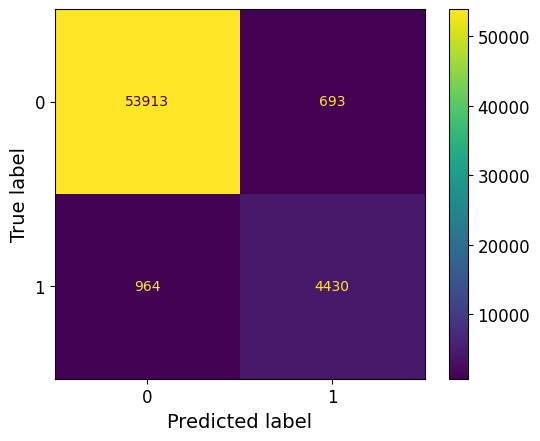

In [97]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix(y_train_5, y_train_pred)).plot()


A perfect binary classifier would be the following

In [98]:
y_train_perfect_predictions = y_train_5

In [99]:
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54606,     0],
       [    0,  5394]])

# Attenzione

Sarebbe comunque sbagliato perché vorrebbe dire che il modello ha appreso a memoria i dati del training set (overfitting). Dunque non sarà bravo a classificare oggetti non appartenenti al training set.

## Precision and Recall
The confusion matrix is the building block for two other measures:

* Precision - it is given by: 
    $$PRECISION = \frac{TP}{TP+FP}$$
    
    It measures how many times
    prediction of a positive sample were actually positive.
    
* Recall - it is given by: $$ RECALL = \frac{TP}{TP+FN}$$

    It measures how many positve samples are captured from the set of all the positive samples.
    
If we apply these measures over the trained classifier we get:

In [100]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)

0.8647276986140933

In [101]:
recall_score(y_train_5, y_train_pred)

0.8212829069336299

See? The model is far from being perfect as the >90% accuracy suggested before.

Precision and recall, combined together, define the so called $F_1$ score denoted as:

$$
F_1 = \frac{2}{\frac{1}{precision} + \frac{1}{recall}} = 2 \times \frac{precision \times recall}{precision +  recall}
$$

The $F_1$ score favors classifiers that have similar precision and recall. 

**Question**: Are precision and recall equally important?

*Answer*....

**Question**: Is there any correlation between precision and recall?

*Answer*....


In [102]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.8424455643244271

In [104]:
from sklearn.linear_model import SGDClassifier
# train it yourself
sgd_clf = SGDClassifier(max_iter=5, tol=1e-3, random_state=42)


sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",5
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None



## Precision/Recall Trade-off

``SGDClassifier`` associates to each point a score, 
based on which it takes its final decision about the class of a sample.

In order to take this decision, sgd uses a threshold value. 
If the score of a sample exceeds this threshold then it is considered
a positive sample.


**Question** How, and to what degree, does the threshold impact on both precision and recall?

*Answer*

---
Let's see what happen when you increase or decrease the threshold.

With  the method ``decision_function`` you can access the score assigned to 
the sample given as input.

In [105]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([-24114.687977])

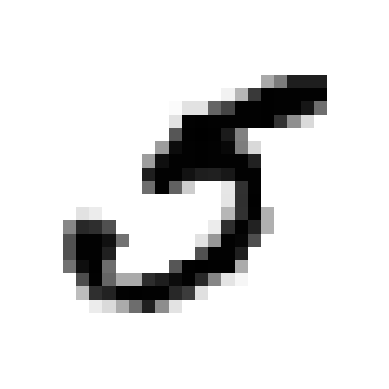

In [106]:
draw(some_digit)

In [107]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [108]:
y_some_digit_pred

array([False])

You can try different values of threshold

In [109]:
threshold = -300000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

If you want to obtain scores instead of classes you can use set ``method="decision_function"``.


In [110]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")
y_scores.shape

(60000,)

In [111]:
y_scores

array([-280572.34776453,  287861.62454378, -148948.30983399, ...,
       -306656.82736805, -955535.27949964, -644983.63496409],
      shape=(60000,))

Setting manually a threshold is not a common approach.

A better way is to plot the precision recall curve.


In [112]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
print(precisions.shape, recalls.shape, thresholds.shape)


(60001,) (60001,) (60000,)


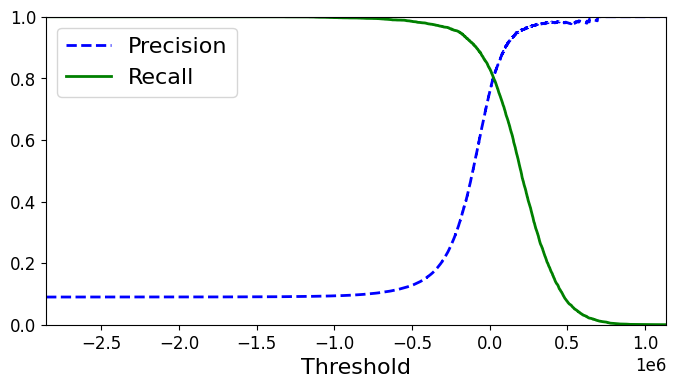

In [113]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.xlabel("Threshold", fontsize=16)
    plt.legend(loc="upper left", fontsize=16)
    plt.ylim([0, 1])

plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.xlim([thresholds.min(), thresholds.max()])

plt.show()

In [114]:
thresholds.max()

np.float64(1134557.4787519933)

Based on this curve you can select the threshold that gives you the best 
precision/recall tradeoff.

Another way to select a good precision/recall tradeoff is to plot
precision directly against recall.

In [115]:
y_train_pred_90 = (y_scores > 70000)

In [116]:
precision_score(y_train_5, y_train_pred_90)

0.8666666666666667

In [117]:
recall_score(y_train_5, y_train_pred_90)

0.7374860956618465

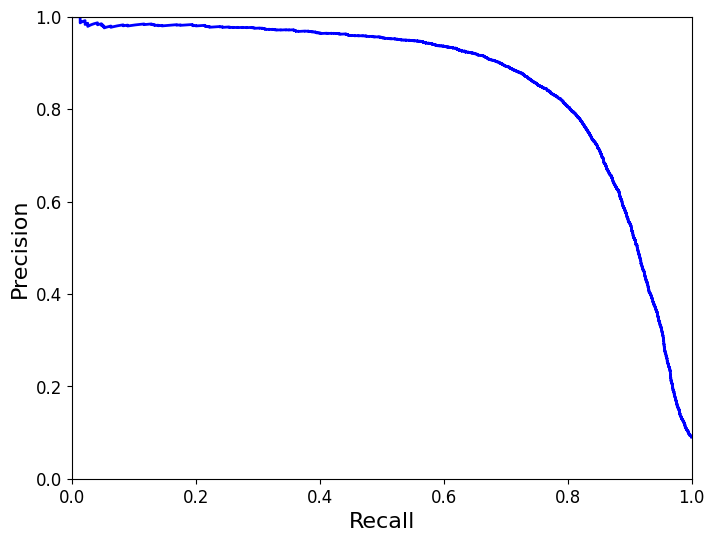

In [118]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)

plt.show()


__Take Home Lesson__

At this point you should be aware of the fact that accuracy is not the only metrics.

Clearly, having 90% precision is not useful if either recall or precision are too low.

## ROC curves
The receiver operating characteristic curve is another common tool used
with binary classifier.

The ROC curve shows the true-positive-rate (another name for Recall) against the false-positive-rate.

This second quantity, the  FPR, is the ratio of negative samples misclassified as positive.

Another quantity is the true-negative-rate, i.e., the ratio of negative samples correctly classified as negative (TNR)

The false positive rate can be computed as $FPR = 1-TNR$

The ROC curve combines all these information.

In short:

* True positive rate (recall / sensitivity)
    $$TPR = \frac{TP}{TP+FN} = 1 - FNR$$

* False positive rate 
    $$
        FPR = \frac{FP}{FP+TN} = 1 - TNR
    $$
* True negative rate (specificity)
    $$
        TNR = \frac{TN}{TN+FP} = 1 - FPR
    $$

To plot the ROC curve, you first need to compute the TPR and FPR for various threshold values, using the  ``roc_curve`` function.

In [119]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

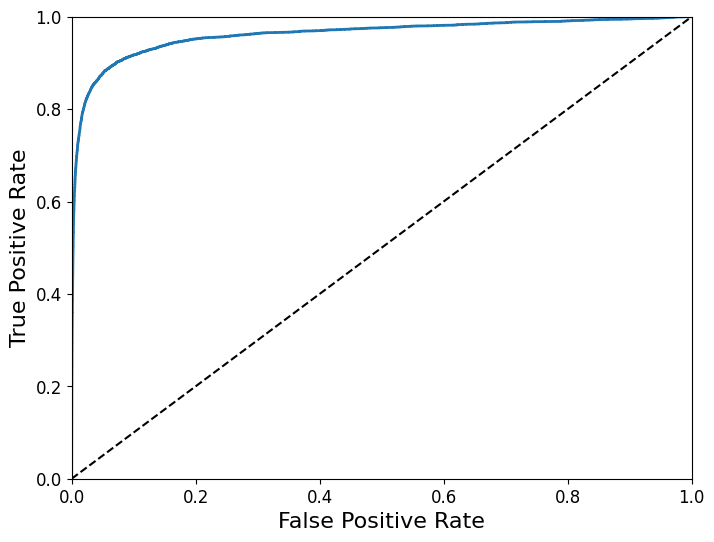

In [120]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
plt.show()

Again, the ROC curve highlights the negative correlation between precision and recall.

In fact, increasing  recall usually leads to decreasing accuracy.

The dotted line represents the ROC curve associated to a purely random classifier. 

The performance of a classifier are proportional to the distance between its 
ROC curve and the one related to the random classifiers.


One can directly measure the area under the ROC curve, that is called AUC.

It must be as closer as possible to one.

sklearn provides a function for computing this area.


In [121]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

0.9617731788978602

### Review

You have seen a number of different ways for measuring the performance of a classifier. 

> How to choose the correct one?

There are general rule of thumbs.

Precision Recall comes in handy when the dataset is unbalanced, with few positive samples
as opposed to negative ones. Also, if you are more interested in keeping false positive low
rather than false negative.

In other situations, ROC/AUC is the way to go.

This result suggests that your model works pretty good. 

However, there is still room for improvement. 
In fact, performance are good because the dataset is strongly unbalanced towards the negative class.


**Exercise**

Train a ``RandomForestClassifier`` (Hint: pass ``predict_proba`` as the ``method`` argument).

Display the ROC curve, precision and recall.

In [122]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=10, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [123]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5,y_scores_forest)

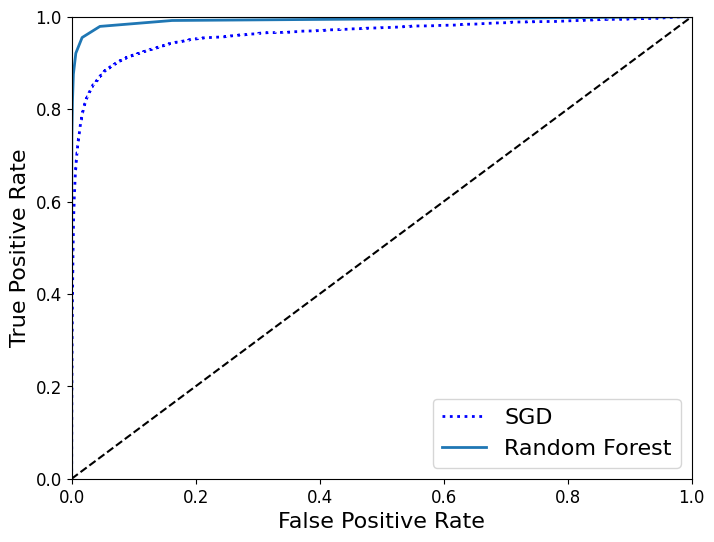

In [124]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right", fontsize=16)

plt.show()

In [125]:
roc_auc_score(y_train_5, y_scores_forest)

0.992348185147165

In [126]:
y_train_pred_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3)
precision_score(y_train_5, y_train_pred_forest)

0.9843470483005367

In [127]:
recall_score(y_train_5, y_train_pred_forest)

0.8160919540229885

# Multiclass classification
From this point on, we will address the original multiclass classification problem.


Instead of having to choose between only a pair of labels, you need to assign a label amongst a number
labels.

Many algorithm like the Random Forest Classifier
or the Naive Bayes Classifier are able to genuinely handle multiclass
classification problems.

However, other algorithm needs to be properly extended in order to 
embrace a multiclass classification problem.

The main strategy is to adapt their binary version.

Two approaches are:

    1. One vs All (OVA) - if you are asked to predict a class amongst N different ones, you can train N different binary classifiers. Each one of them is trained in order to detect a single class against all the others.
    
    2. One vs One (OVO) - given N different class, you can  N x (N-1)/2 different binary classifier. You will need to train a classifier for every possible pair of classes.

For most binary classification algorithms the OVA approach is the one adopted by default.

sklearn automatically detects when you need to solve a multiclass classification problem.


In [128]:
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([5], dtype=int8)

In [129]:
y_train

array([3, 5, 3, ..., 9, 0, 2], shape=(60000,), dtype=int8)

Actually, under the hood,
scikit-Learn actually trained 10 binary classifiers, got their decision scores for the
image, and selected the class with the highest score.

To convince yourself about the actual strategy adopted by sklearn you can 
compute the scores associated with the ``some_digit``.

In [130]:
some_digit_scores = sgd_clf.decision_function([some_digit])
some_digit_scores

array([[-133769.26576778, -468173.90755635, -512604.13843102,
         -43693.43765314, -376477.31348056,  217539.97888698,
        -727789.31035672, -421708.08915195, -648429.41883696,
        -509763.20556354]])

Each score  **reflects** a 'score', i.e., the likelihood the a certain sample belongs to 
the corresponding class.

The class is assigned computing the argmax on this vector of scores

In [131]:
np.argmax(some_digit_scores)

np.int64(5)

**Note**: Be careful, this 5 actually is the index of the maximum element, not the class!

The classes upon which the classifier is trained can be accessed via the ``classes_`` field of the estimator

In [132]:
sgd_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int8)

In [133]:
sgd_clf.classes_[5]

np.int8(5)

You can force sklearn to adopt the OVO by wrapping a classifier with the
``OneVsOneClassifier`` .
You need to pass a regular binary classifier and then call the usual fit method.

In [134]:
from sklearn.multiclass import OneVsOneClassifier
ovo_clf = OneVsOneClassifier(SGDClassifier(max_iter=5, tol=1e-3, random_state=42))
ovo_clf.fit(X_train, y_train)
ovo_clf.predict([some_digit])


array([5], dtype=int8)

In [135]:
len(ovo_clf.estimators_)

45

Now, try with a **RandomForestClassifier**

In [136]:
forest_clf.fit(X_train, y_train)
forest_clf.predict([some_digit])

array([5], dtype=int8)

In [137]:
y_train

array([3, 5, 3, ..., 9, 0, 2], shape=(60000,), dtype=int8)

In [138]:
forest_clf.predict_proba([some_digit])

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]])

In [139]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.86875, 0.8745 , 0.85195])

It gets over 84% on all test folds. 

A random classifier would get 10% accuracy, not a bad score.
But you can improve.

We did not use any preprocessing techniques yet.



In [140]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

p = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', sgd_clf)
])

cross_val_score(p, X_train, y_train, cv=3, scoring="accuracy")

array([0.91235, 0.9097 , 0.9086 ])

## Error Analysis
Let assume we found a promising model.

One thing to do is to evaluate its errors.

You need to make predictions using the ``cross_val_predict`` fnction and then
call the ``confusion_matrix()`` function, just like
you did earlier:

In [141]:
X_train_scaled = StandardScaler().fit_transform(X_train)
y_train_pred =  cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

array([[5751,    3,   24,   10,   10,   36,   44,   10,   30,    3],
       [   2, 6494,   43,   28,    5,   35,   10,   12,  115,    9],
       [  57,   32, 5370,   95,   95,   21,   81,   56,  169,   15],
       [  41,   37,  134, 5401,    2,  206,   33,   50,  134,   95],
       [  13,   28,   54,    8, 5418,    8,   56,   37,   82,  192],
       [  76,   41,   45,  198,   82, 4553,  106,   33,  172,   88],
       [  34,   25,   56,    4,   41,  108, 5528,    6,   42,    0],
       [  30,   24,   75,   26,   58,   11,    4, 5788,   20,  188],
       [  48,  136,   74,  157,   16,  151,   64,   35, 5031,  127],
       [  45,   35,   31,   82,  158,   36,    2,  229,   79, 5308]])

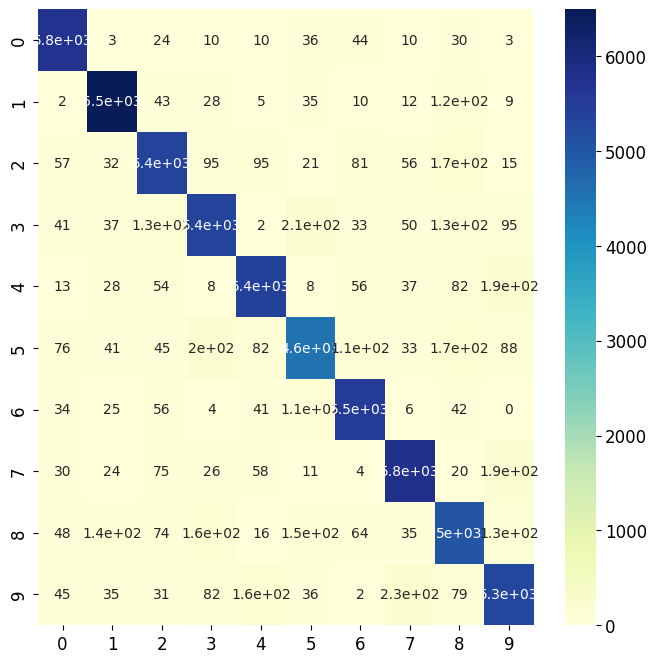

In [142]:
import seaborn as sns
def plot_confusion_matrix(matrix):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111)
    sns.heatmap(matrix, 
                annot=True,  
                cmap="YlGnBu")
            
plot_confusion_matrix(conf_mx)

Let’s focus the plot on the errors. 

First, you need to divide each value in the confusion
matrix by the number of images in the corresponding class, so you can compare error
rates instead of absolute number of errors.


In [143]:
row_sums = conf_mx.sum(axis=1, keepdims=True) # num of samples for each class
col_sum = conf_mx.sum(axis=0, keepdims=True)  # num of predictions for each class
norm_conf_mx = conf_mx / row_sums


Now let’s fill the diagonal with zeros to keep only the errors, and plot the result:

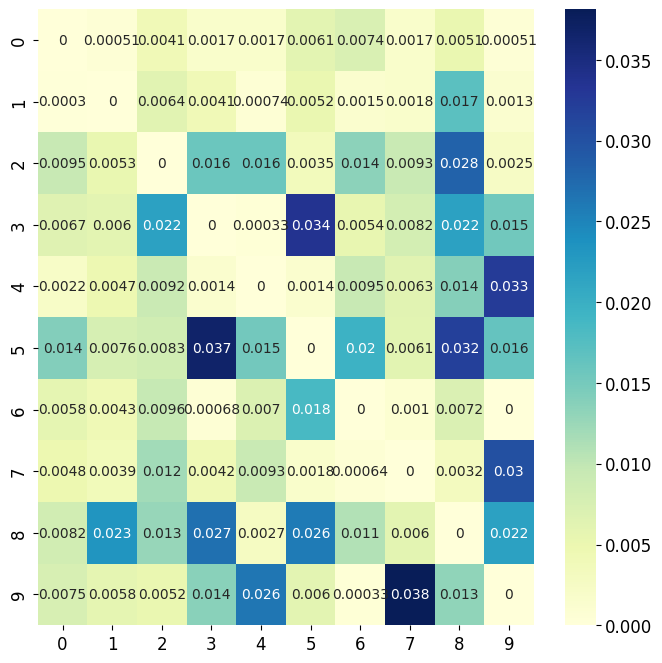

In [144]:
np.fill_diagonal(norm_conf_mx, 0)
plot_confusion_matrix(norm_conf_mx)

The columns corresponding to 8 and 9 are quite dark,
which tells you that many images get misclassified as 8s or 9s. 

Similarly, the rows for classes 8 and 9 are also quite dark, telling you that 8s
and 9s are often confused with other digits. 

Conversely, some rows are pretty bright,
such as ow 1: this means that most 1s are classified correctly.

# Multilabel classification

Until now each instance has always been assigned to just one class. In some cases you
may want your classifier to output multiple classes for each instance. For example,
consider a face-recognition classifier: what should it do if it recognizes several people
on the same picture?

Such a classification system that outputs multiple
binary labels is called a multilabel classification system.

In [145]:
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [146]:
y_multilabel

array([[False,  True],
       [False,  True],
       [False,  True],
       ...,
       [ True,  True],
       [False, False],
       [False, False]], shape=(60000, 2))

This code creates a y_multilabel array containing two target labels for each digit
image: the first indicates whether or not
the digit is large (7, 8, or 9) and the second
indicates whether or not it is odd. The next lines create a KNeighborsClassifier,
Now you can make a prediction, and notice
that it outputs two labels:

In [147]:
some_digit

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,  86, 131, 225, 225, 225,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [148]:
knn_clf.predict([some_digit])

array([[False,  True]])

And it gets it right! The digit 5 is indeed not large ( False ) and odd ( True ).

There are many ways to evaluate a multilabel classifier, and selecting the right metric
really depends on your project. For example, one approach is to measure the F 1 score
for each individual label (or any other binary classifier metric discussed earlier), then
simply compute the average score. This code computes the average F 1 score across all
labels:

In [149]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3, n_jobs=-1)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9761165233071007

This assumes that all labels are equally important, which may not be the case.

One simple option is to give each label a weight equal to its support (i.e., the number of instances with that
target label). To do this, simply set average="weighted" in the preceding code.

# Exercises
Train different classifiers and test their performance on the test set

## KNN classifier

## SVM

# Decision Tree 

## Logistic Regression

## An MNIST Classifier With Over 97% Accuracy

KNeighbors seems to perform fine. Try to push its performance with 
automated parameter tuning. 

The algorithm has just one parameter: k, which represents the n

In [150]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'weights': ["uniform", "distance"], 
               'n_neighbors': [3, 4, 5]}]

knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5, verbose=3, n_jobs=4)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ....n_neighbors=3, weights=uniform;, score=0.973 total time=  20.8s
[CV 2/5] END ....n_neighbors=3, weights=uniform;, score=0.970 total time=  21.6s
[CV 4/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time=  21.7s
[CV 3/5] END ....n_neighbors=3, weights=uniform;, score=0.971 total time=  21.8s
[CV 5/5] END ....n_neighbors=3, weights=uniform;, score=0.970 total time=  17.6s
[CV 1/5] END ...n_neighbors=3, weights=distance;, score=0.974 total time=  17.5s
[CV 3/5] END ...n_neighbors=3, weights=distance;, score=0.973 total time=  18.8s
[CV 2/5] END ...n_neighbors=3, weights=distance;, score=0.971 total time=  18.9s
[CV 4/5] END ...n_neighbors=3, weights=distance;, score=0.971 total time=  12.9s
[CV 5/5] END ...n_neighbors=3, weights=distance;, score=0.971 total time=  13.5s
[CV 1/5] END ....n_neighbors=4, weights=uniform;, score=0.972 total time=  18.5s
[CV 2/5] END ....n_neighbors=4, weights=uniform;,

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'n_neighbors': [3, 4, ...], 'weights': ['uniform', 'distance']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

In [151]:
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [152]:
grid_search.best_score_

np.float64(0.9724666666666666)

In [153]:
from sklearn.metrics import accuracy_score

y_pred = grid_search.predict(X_test)
accuracy_score(y_test, y_pred)

0.9756

In [154]:
knn_clf.fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9724

## Testing and Selecting the best Model
Now, you are required to build an entire pipeline. 
You need to select a number of models, tuning upon each of them and then you need to report in a table the following
information:

1. Name of The estimator
2. Best Configuration
3. accuracy
3. precision
4. recall
5. AUC score

Of course, these results must be obtained wrt the test set.